In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle

import subcluster_funcs as funcs
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)

In [3]:
cell_type = "Endocardial"

In [4]:
adata = sc.read_h5ad("../post_subclustering/" + cell_type  + ".h5ad")

<Axes: xlabel='leiden', ylabel='sil_score'>

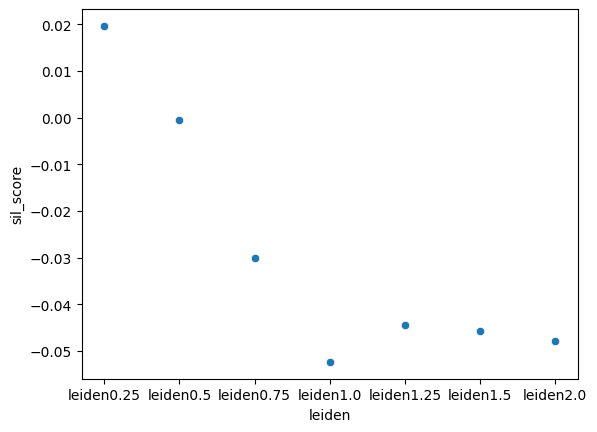

In [5]:
funcs.silhouette(adata, cell_type = cell_type)

### Leiden 0.25

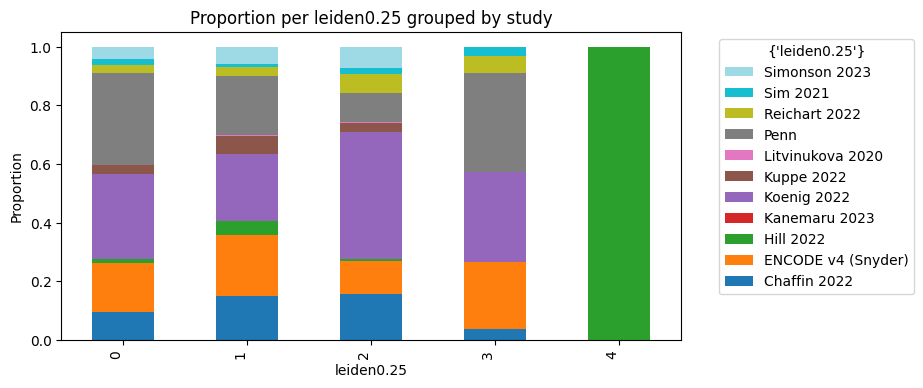

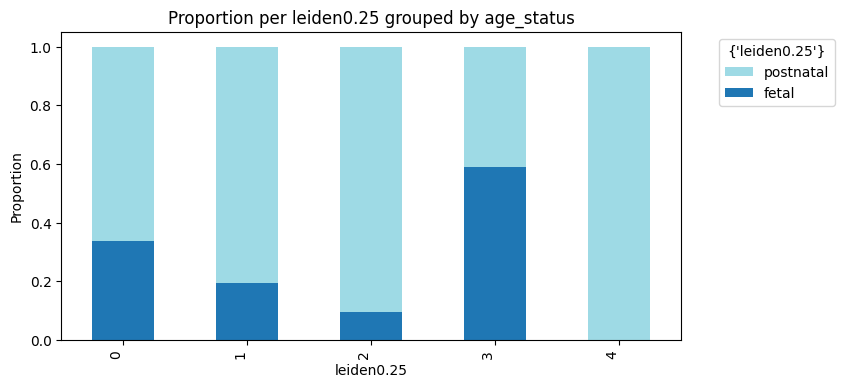

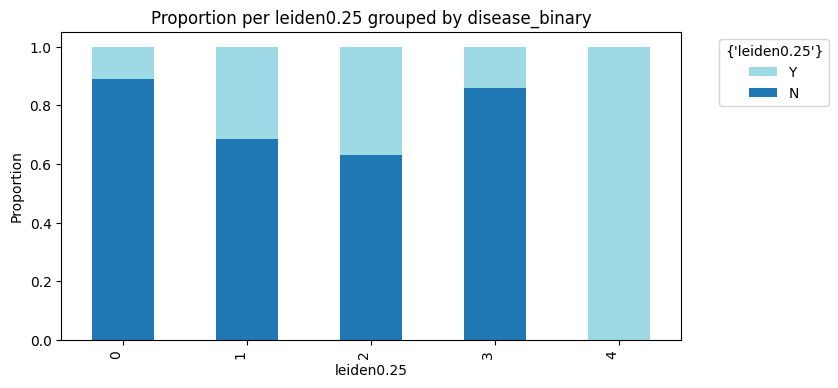

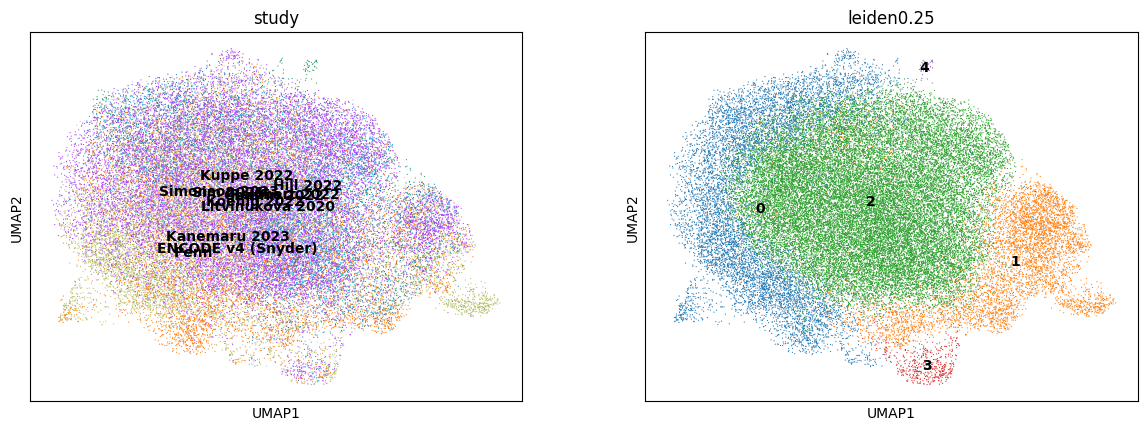

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean

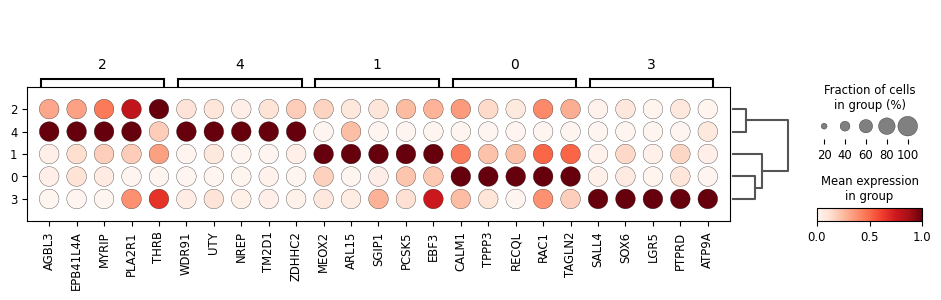

Counter({'2': 27552, '0': 8924, '1': 5594, '3': 470, '4': 42})


['leiden0.25',
 AnnData object with n_obs × n_vars = 42582 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0'
     var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'leiden1.75', 'leiden2.0', 'neighbors', 'pca', 'rank_genes_groupsleiden0.1', 'rank_genes_groupsleiden0.25', 'rank_genes_groupsleiden0.5', 'rank_genes_groupsleiden0.75', 'rank_genes_groupsleiden1.0', '

In [6]:
funcs.specify_leiden_subclustering(adata=adata, leiden="leiden0.25")

- Cluster 0 are ventricular endocardial cells (RAC1/RHOA/RHOC) with migratory phenotypes (ARF1/ARF6, DYNC1I2, KIF5B, TUBA1B)
- Cluster 1 are valvular endocardial cells with mesenchymal markers: MEOX1/MEOX2; signaling: NOTCH3/CHRNA1/SCN3A)  
- Cluster 2 are have expression of BMPR1B and also have a migratory phenotype: CLASP1, MKLN1, RALGAPA2; likely still ventricular
- Cluster 3 are immature endocardial cells (SALL4/SOX6/LGR5); enriched for fetal cells
- Cluster 4 is primarily from one study, very small cluster, most similar to cluster 2

{'mainplot_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

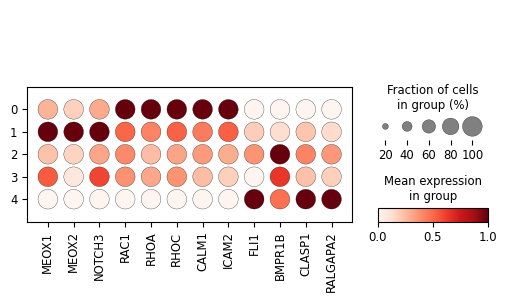

In [7]:
sc.pl.dotplot(adata, var_names = ["MEOX1", "MEOX2", "NOTCH3",
                                       "RAC1", "RHOA", "RHOC", "CALM1", "ICAM2",
                                  "FLI1", "BMPR1B", "CLASP1", "RALGAPA2"],
              groupby = "leiden0.25", show=False, standard_scale='var', layer="scvi_normalized")

In [8]:
#sc.get.rank_genes_groups_df(adata, group="2").head(40)['names']

In [9]:
adata.obs['subcluster'] = adata.obs['leiden0.25'].map(
    {"0": "Ventricular",
     "1": "Valvular",
     "2": "Ventricular",
     "3": "Immature",
     "4": "Ventricular",
    }
)

In [10]:
subcluster_order = [
    "Ventricular",
    "Valvular",
    "Immature"]

adata.obs['subcluster'] = pd.Categorical(
    adata.obs['subcluster'], categories=subcluster_order, ordered=True
)

# Define colors for each subcluster
subcluster_colors = {
    "Ventricular": "orange",       
    "Valvular": "cyan",     
    "Immature": "red"
}

adata.uns['subcluster_colors'] = [subcluster_colors[sc] for sc in subcluster_order]

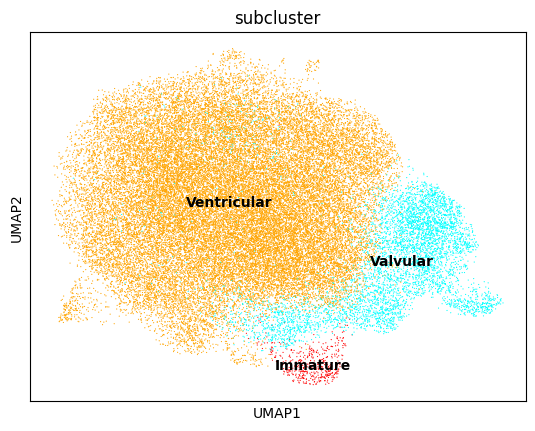

In [11]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette=subcluster_colors, show=False)
    plt.savefig("Endocardial_subclustered.pdf", bbox_inches="tight")

- Cluster 0 are ventricular endocardial cells (RAC1/RHOA/RHOC) with migratory phenotypes (ARF1/ARF6, DYNC1I2, KIF5B, TUBA1B)
- Cluster 1 are valvular endocardial cells with mesenchymal markers: MEOX1/MEOX2; signaling: NOTCH3/CHRNA1/SCN3A)  
- Cluster 2 are have expression of BMPR1B and also have a migratory phenotype: CLASP1, MKLN1, RALGAPA2; likely still ventricular
- Cluster 3 are immature endocardial cells (SALL4/SOX6/LGR5); enriched for fetal cells
- Cluster 4 is primarily from one study, very small cluster, most similar to cluster 2

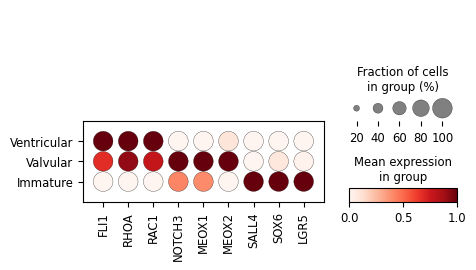

In [12]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = ["FLI1", "RHOA", "RAC1",
                                       "NOTCH3", "MEOX1", "MEOX2",
                                       "SALL4", "SOX6", "LGR5"], 
              groupby = "subcluster", show=False, standard_scale='var', layer="scvi_normalized")
    plt.savefig("Endocardial_subclustered_dotplot.pdf", bbox_inches="tight")

In [13]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

    subcluster  count  proportion
0  Ventricular  36518    0.857592
1     Valvular   5594    0.131370
2     Immature    470    0.011038
